# Module 2 — Exercises (Student Worksheet)
### Graphs, Message Passing, EdgeConv & ParticleNet · TIFR ML School 2026

Student worksheet for the six exercises at the end of
`Module2_Graphs_MessagePassing_ParticleNet.ipynb`. **Self-contained**: the *Setup* section re-defines the
k-NN graph builder, EdgeConv/ParticleNet/GravNet, and loads JetClass into PyG `Data` objects.

| # | Exercise | Idea it drives home |
|---|----------|---------------------|
| 1 | **k matters** | neighbourhood size is an accuracy/compute knob |
| 2 | **Static vs dynamic** | rebuilding the graph in learned space is what makes ParticleNet more than a fixed-graph GNN |
| 3 | **Aggregator** | `sum`/`mean`/`max` over *fixed-k* neighbours — and why that differs from Module-1 pooling |
| 4 | **Edge features** | does handing the net ΔR help, or does `x_j−x_i` already contain it? |
| 5 | **Train GravNet** | a *learned* neighbourhood space vs a recomputed k-NN |
| 6 | **PFN vs ParticleNet** | *where* on the ROC do edges actually pay off |

> **One design choice that pays off everywhere:** we make `ParticleNet` **configurable** (`k`, `aggr`,
> `dynamic`), so exercises 1–3 are just three different constructor calls on the same class. And a PFN over
> a PyG batch is literally `global_add_pool(φ(x), batch)` — so we can run the PFN on the **identical** graph
> splits used for ParticleNet (exercise 6's "same test jets", for free).
>
> **Speed knobs:** `N_PER_CLS` and `EPOCHS`. Defaults run in a few minutes on a laptop; raise to sharpen.

> **How to use this worksheet.** Run the **Setup** section as-is (it loads the data and provides the models/helpers from the module). Then complete each exercise where you see `# TODO` and `raise NotImplementedError`. Read the **prompt** above each exercise — it sketches the approach. Check your work against the matching `*_Exercises_Solutions.ipynb`.

## Setup — imports, graph machinery, data, models

In [14]:
import os, time, random, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import torch_geometric
from torch_geometric.nn import MessagePassing, global_mean_pool, global_add_pool
from torch_geometric.utils import scatter
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.metrics import roc_auc_score, roc_curve

torch.manual_seed(0); np.random.seed(0); random.seed(0)
device = (torch.device("cuda") if torch.cuda.is_available()
          else torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cpu"))
print("torch", torch.__version__, "| PyG", torch_geometric.__version__, "| device", device)

torch 2.13.0 | PyG 2.8.0.post1 | device mps


In [ ]:
# ========================================================================================
# GRAPH NEURAL NETWORKS: K-NEAREST NEIGHBORS (KNN) & EDGE CONVOLUTION
# ========================================================================================
# This section defines the fundamental building blocks for Dynamic Graph CNNs (DGCNN),
# treating physics jets not as unordered sets, but as interconnected geometric graphs.

# ----------------------------------------------------------------------------------------
# 1. BATCHED K-NEAREST NEIGHBORS (k-NN) GRAPH GENERATOR
# ----------------------------------------------------------------------------------------
def knn_graph_native(x, k, batch):
    """
    Constructs a directed k-NN graph on the fly.
    Returns an edge_index tensor of shape [2, E] where row 0 is source (j) and row 1 is target (i).
    """
    with torch.no_grad():
        N = x.size(0)

        # Calculate the squared L2 (Euclidean) norm for every particle.
        # Math: $||x||^2 = \sum (x_d)^2$
        x2 = (x * x).sum(1, keepdim=True)

        # Calculate the pairwise squared Euclidean distance matrix using the algebraic expansion:
        # Math: $d(x_i, x_j)^2 = ||x_i - x_j||^2 = ||x_i||^2 + ||x_j||^2 - 2(x_i \cdot x_j)$
        # x2 is $||x_i||^2$, x2.t() is $||x_j||^2$, and (x @ x.t()) is the dot product matrix.
        dist2 = x2 + x2.t() - 2.0 * (x @ x.t())
        # dist2= result[i, j] = Sum (x[i, k] * x[j, k])   for k = 1 to D

        # The 'batch' tensor assigns an integer ID to every particle, mapping it to its parent jet.
        # We compute a boolean matrix checking if particle 'i' and particle 'j' belong to the same jet.

        same = (batch.unsqueeze(0) == batch.unsqueeze(1))
        #Layman Example for me:
        #batch = torch.tensor([3, 7, 3, 5])
        # batch.unsqueeze(0) -> [[3, 7, 3, 5]]  (shape [1,4])
        # batch.unsqueeze(1) -> [[3], [7], [3], [5]]  (shape [4,1])

        # Result (shape [4,4]):
        # [[ True, False,  True, False],   # element 0 (3) vs all
        #  [False,  True, False, False],   # element 1 (7) vs all
        #  [ True, False,  True, False],   # element 2 (3) vs all
        #  [False, False, False,  True]]   # element 3 (5) vs all

        # Prevent particles from connecting across different jets by forcing inter-jet distances to infinity.
        dist2 = dist2.masked_fill(~same, float("inf"))
        #  Updated dist2, example for me:
        # [[0.0, inf, 2.0],   # row0: distances to class 0 only (self and sample2)
        #  [inf, 0.0, inf],   # row1: only self (no other class 1 samples)
        #  [2.0, inf, 0.0]]   # row2: only class 0 samples

        # Prevent self-loops (a particle being its own nearest neighbor) by setting the diagonal to infinity.
        dist2.fill_diagonal_(float("inf"))

        # Cap 'k' to ensure we do not request more neighbors than physically exist in the smallest graph.
        kk = min(k, max(N - 1, 1))

        # Extract the indices of the 'kk' smallest distances along the columns (dim=1).
        knn_d, idx = dist2.topk(kk, dim=1, largest=False)

        # Create a validity mask to drop edges where the distance remained infinity
        # (which happens if a jet has fewer than 'kk' particles).
        valid = torch.isfinite(knn_d)

        # Create an array of target node IDs (the center particles receiving the incoming edges)
        # and expand it to match the shape of the neighbor matrix.
        centre = torch.arange(N, device=x.device).unsqueeze(1).expand(-1, kk)

        # torch.stack binds the 1D arrays of neighbors (sources, index 0) and centers (targets, index 1).
        return torch.stack([idx[valid], centre[valid]], dim=0)


# ----------------------------------------------------------------------------------------
# 2. THE EDGE CONVOLUTION OPERATOR (MessagePassing)
# ----------------------------------------------------------------------------------------
class EdgeConv(MessagePassing):
    """
    Implements the core operation of Dynamic Graph CNNs.
    Instead of computing features strictly on nodes, it computes features on the edges,
    capturing local geometric structure before aggregating.

    The Math: $x_i^{\prime} = \bigoplus_{j \in \mathcal{N}(i)} \text{MLP}(x_i \,||\, x_j - x_i)$
    where $\bigoplus$ is the aggregation operator (e.g., mean) and $||$ is concatenation.
    """

    def __init__(self, in_c, out_c, aggr="mean"):
        # Inherit from PyTorch Geometric's MessagePassing base class.
        super().__init__(aggr=aggr)

        # The Multi-Layer Perceptron (MLP) that processes the edge geometries.
        # Input dimension is 2 * in_c because we concatenate $x_i$ and the difference vector $(x_j - x_i)$.
        # BatchNorm1d stabilizes the internal covariate shift during training.
        self.mlp = nn.Sequential(
            nn.Linear(2 * in_c, out_c),
            nn.BatchNorm1d(out_c),
            nn.ReLU(),
            nn.Linear(out_c, out_c),
            nn.BatchNorm1d(out_c),
            nn.ReLU(),
        )

    def forward(self, x, edge_index):
        # The entry point. 'propagate' is an internal method from MessagePassing that automatically
        # handles the complex scatter/gather routing required to move data along the edge_index.
        return self.propagate(edge_index, x=x)

    def message(self, x_i, x_j):
        # In PyTorch Geometric nomenclature:
        # x_i represents the central/target node receiving the information.
        # x_j represents the neighboring/source node sending the information.
        # We explicitly calculate the asymmetric geometric directional difference: $(x_j - x_i)$.
        # torch.cat bundles the global position ($x_i$) and the local structural difference ($x_j - x_i$).
        return self.mlp(torch.cat([x_i, x_j - x_i], dim=-1))


# ----------------------------------------------------------------------------------------
# 3. EDGE CONVOLUTION RESIDUAL BLOCK
# ----------------------------------------------------------------------------------------
class EdgeConvBlock(nn.Module):
    """
    Wraps the EdgeConv operator inside a ResNet-style residual block.
    This prevents the vanishing gradient problem, allowing the construction of deep graph networks.

    Math: $x_i^{(l+1)} = \text{ReLU}\left(\text{EdgeConv}(x_i^{(l)}) + W \cdot x_i^{(l)}\right)$
    """

    def __init__(self, in_c, out_c, aggr="mean"):
        super().__init__()

        # The primary spatial convolution operator.
        self.conv = EdgeConv(in_c, out_c, aggr)

        # The residual shortcut pathway.
        # If the input and output channel dimensions differ, we use a simple linear projection matrix ($W$)
        # to map $x$ to the correct dimensional size so addition is mathematically valid.
        self.shortcut = nn.Linear(in_c, out_c)
        self.act = nn.ReLU()

    def forward(self, x, edge_index):
        # Execute the primary convolution.
        conv_out = self.conv(x, edge_index)

        # Execute the linear projection on the raw inputs.
        skip_out = self.shortcut(x)

        # Add the two signals algebraically, then pass through the non-linear activation.
        return self.act(conv_out + skip_out)


<>:80: SyntaxWarning: invalid escape sequence '\p'
<>:122: SyntaxWarning: invalid escape sequence '\l'
<>:80: SyntaxWarning: invalid escape sequence '\p'
<>:122: SyntaxWarning: invalid escape sequence '\l'
/var/folders/0s/9r0n20j90w36bt6vmbn27lp40000gn/T/ipykernel_55082/1221406505.py:80: SyntaxWarning: invalid escape sequence '\p'
  Math: $x_i^{\prime} = \bigoplus_{j \in \mathcal{N}(i)} \text{MLP}(x_i \,||\, x_j - x_i)$
/var/folders/0s/9r0n20j90w36bt6vmbn27lp40000gn/T/ipykernel_55082/1221406505.py:122: SyntaxWarning: invalid escape sequence '\l'
  Math: $x_i^{(l+1)} = \text{ReLU}\left(\text{EdgeConv}(x_i^{(l)}) + W \cdot x_i^{(l)}\right)$


In [16]:
# ========================================================================================
# PARTICLE NET (DYNAMIC GRAPH CNN)
# ========================================================================================
# ParticleNet treats a jet as a point cloud / graph. This implementation is configurable
# to demonstrate different architectural choices (k-neighbors, static vs dynamic, aggregation).

class ParticleNet(nn.Module):
    def __init__(self, in_feat, n_classes=2, k=8, conv_channels=(32,64,64), fc=128,
                 dropout=0.1, aggr="mean", dynamic=True):
        super().__init__()
        # k: number of nearest neighbors to connect.
        # dynamic: if True, the graph topology is recomputed in the latent space after every layer.
        self.k, self.dynamic = k, dynamic

        # Build the sequence of channel dimensions (e.g., [7, 32, 64, 64])
        chans = [in_feat, *conv_channels]

        # nn.ModuleList holds the EdgeConvBlocks. We cannot use nn.Sequential here because
        # EdgeConvBlock requires two inputs (features and edge_index), which Sequential doesn't support.
        self.blocks = nn.ModuleList([EdgeConvBlock(chans[i], chans[i+1], aggr)
                                     for i in range(len(conv_channels))])

        # The global classification head. Applies Dropout to randomly zero out 10% of neurons
        # during training to prevent overfitting.
        self.head = nn.Sequential(nn.Linear(conv_channels[-1], fc), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(fc, n_classes))
        self.last_edges = []

    def forward(self, data):
        # PyTorch Geometric (PyG) batches graphs by concatenating all nodes from all jets
        # into one massive 1D list, and uses a 'batch' array to remember which node belongs to which jet
        # (e.g., [0,0,0, 1,1,1,1, 2,2]). If missing, assume it's a single jet (all 0s).
        batch = data.batch if getattr(data, "batch", None) is not None \
                else torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)

        # feats: The physical variables (pT, energy, etc.) used to compute node features.
        # coords: The spatial variables used to compute geometric distance for the k-NN graph.
        feats, coords = data.x, data.pos
        self.last_edges = []

        for block in self.blocks:
            # Construct the directed edges.
            # In Block 0, 'coords' are physical angles (eta, phi).
            edge_index = knn_graph_native(coords, self.k, batch)
            self.last_edges.append(edge_index)

            # Pass the features through the Edge Convolution MLP.
            feats = block(feats, edge_index)

            # THE DYNAMIC GRAPH CNN (DGCNN) MECHANISM:
            # If dynamic=True, we overwrite the physical spatial coordinates with the newly
            # learned, high-dimensional abstract features.
            # In the next loop iteration, knn_graph_native will connect particles that are
            # "close" in abstract feature space (e.g., particles with similar kinematics),
            # not just particles that are physically close in the detector.
            if self.dynamic:
                coords = feats

        # global_mean_pool acts exactly like our old masked_mean.
        # It looks at the 'batch' index array and calculates the separate average feature vector
        # for Jet 0, Jet 1, Jet 2, etc., collapsing the point cloud into a single vector per jet.
        return self.head(global_mean_pool(feats, batch))


# ========================================================================================
# PARTICLE FLOW NETWORK (PYTORCH GEOMETRIC IMPLEMENTATION)
# ========================================================================================
# This is the exact same Deep Sets architecture from Exercise 1, rewritten to use
# PyG's sparse graph batching instead of the dense padded (Batch, Max_Particles) tensors.

class PFN(nn.Module):
    def __init__(self, in_feat, n_classes=2, hidden=(64,128,128), latent=128):
        super().__init__()
        # Build the Phi network to embed per-particle features.
        dims = [in_feat, *hidden]; layers = []
        for a, b in zip(dims[:-1], dims[1:]): layers += [nn.Linear(a, b), nn.ReLU()]
        self.phi = nn.Sequential(*layers, nn.Linear(hidden[-1], latent))

        # Build the F network for final classification.
        self.head = nn.Sequential(nn.Linear(latent, 128), nn.ReLU(), nn.Linear(128, n_classes))

    def forward(self, data):
        # Ensure the batch index array exists for routing.
        batch = data.batch if getattr(data, "batch", None) is not None \
                else torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)

        # 1. self.phi(data.x) applies the MLP to every node independently.
        # 2. global_add_pool replaces our custom 'masked_sum'. It aggregates all nodes
        #    belonging to the same jet ID into a single summed vector.
        # 3. self.head(...) decodes that sum into the final class logits.
        return self.head(global_add_pool(self.phi(data.x), batch))


# ========================================================================================
# GRAVNET LAYER (DISTANCE-WEIGHTED MESSAGE PASSING)
# ========================================================================================
# GravNet is an alternative to ParticleNet. Instead of EdgeConv (which uses an MLP on
# concatenated node pairs), GravNet projects particles into a low-dimensional "spatial"
# coordinate system, calculates a Gaussian gravitational potential, and scales features by distance.

class GravNetLayer(nn.Module):
    def __init__(self, in_c, out_c, space_dim=4, prop_dim=22, k=8):
        super().__init__(); self.k = k

        # lin_s: Projects input features down to a small, abstract spatial coordinate space (s).
        # We will use these coordinates strictly to measure distance and build the graph.
        self.lin_s = nn.Linear(in_c, space_dim)

        # lin_f: Projects input features into a different feature space (f).
        # We will use these as the actual "messages" sent between particles.
        self.lin_f = nn.Linear(in_c, prop_dim)

        # lin_out: The final MLP that combines the aggregated messages with the original inputs.
        # Input dimension: Original features (in_c) + Mean-pooled messages (prop_dim) + Max-pooled messages (prop_dim).
        self.lin_out = nn.Sequential(nn.Linear(in_c + 2*prop_dim, out_c), nn.ReLU())

    def forward(self, x, batch):
        # Generate the learned coordinates (s) and the learned messages (f).
        s, f = self.lin_s(x), self.lin_f(x)

        # Build the k-NN graph in the newly learned 's' coordinate space.
        # j is the array of source nodes, i is the array of target nodes.
        j, i = knn_graph_native(s, self.k, batch)

        # Calculate the squared Euclidean distance d^2 between source (s[j]) and target (s[i]).
        # .sum(-1, keepdim=True) collapses the coordinate dimensions into a single scalar distance per edge.
        d2 = ((s[i] - s[j])**2).sum(-1, keepdim=True)

        # The Gravitational Potential / Gaussian Attention mechanism.
        # w = exp(-d^2) maps distance to a weight between 0.0 and 1.0.
        # Particles extremely close in 's' space get a weight near 1.0. Far particles approach 0.0.
        w = torch.exp(-d2)

        # Multiply the message vector from the source node (f[j]) by the distance weight.
        msg = f[j] * w

        # Scatter is PyG's low-level aggregation tool.
        # It takes the list of weighted messages and routes them to their specific target node IDs (i).
        # We do this twice: once to calculate the mathematical mean of incoming messages,
        # and once to calculate the maximum incoming message feature-by-feature.
        a_mean = scatter(msg, i, dim=0, dim_size=x.size(0), reduce="mean")
        a_max  = scatter(msg, i, dim=0, dim_size=x.size(0), reduce="max")

        # Concatenate the original raw features with the two sets of aggregated graph features,
        # and pass them through the final output MLP to produce the new node representations.
        return self.lin_out(torch.cat([x, a_mean, a_max], dim=-1))

In [17]:
# ========================================================================================
# DATASET LOADING AND AWKWARD ARRAY (JAGGED DATA) PROCESSING
# ========================================================================================
import uproot
import awkward as ak
import numpy as np
import os
import torch
import random
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

# ----------------------------------------------------------------------------------------
# 1. FILE DISCOVERY AND EXTRACTION
# ----------------------------------------------------------------------------------------
# Define potential file paths. next() scans the list and returns the first path that physically exists.
CANDIDATE_PATHS = [
    "../data/JetClass_example_100k.root",
    "/Users/sanmay/Documents/ML_SCHOOLS/MLSCHOOL_2023_ICTS/Main_School/JetDataset/JetClass_example_100k.root",
    "./JetClass_example_100k.root",
]
root_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if root_path is None:
    raise FileNotFoundError("JetClass_example_100k.root not found")
print("Using:", root_path)

MAX_PART  = 128
# N_PER_CLS sets the strict upper limit for how many jets of each class to load.
# Lowering this prevents RAM blowouts on consumer hardware.
N_PER_CLS = 2000
EPOCHS    = 6

# uproot opens the .root binary file. ["tree"] accesses the main data structure.
tree = uproot.open(root_path)["tree"]

# tree.arrays reads the requested columns into memory as "Awkward Arrays" (ak).
# Awkward Arrays are specifically designed for physics data because particle collisions
# produce a different number of particles every time.
# Standard NumPy requires perfectly rectangular grids (N_jets x N_particles),
# but Awkward Arrays natively support jagged structures (lists of lists of varying lengths).
br = tree.arrays(["part_px","part_py","part_pz","part_energy","part_deta","part_dphi",
                  "label_QCD","label_Tbqq","label_Tbl"])


# ----------------------------------------------------------------------------------------
# 2. BOOLEAN MASKING AND BALANCED SUBSETTING
# ----------------------------------------------------------------------------------------
# Convert jagged awkward arrays directly into flat NumPy boolean arrays for the class labels.
is_qcd = ak.to_numpy(br["label_QCD"]).astype(bool)

# Top quarks decay via multiple channels. The bitwise OR (|) combines them.
is_top = ak.to_numpy(br["label_Tbqq"]).astype(bool) | ak.to_numpy(br["label_Tbl"]).astype(bool)

# np.where(...)[0] gets the exact row indices where the mask is True.
# [:N_PER_CLS] slices exactly 2,000 indices from each class to guarantee a perfectly balanced dataset.
sel = np.concatenate([np.where(is_qcd)[0][:N_PER_CLS], np.where(is_top)[0][:N_PER_CLS]])

# Generate the Y-target vector: 2,000 zeros (QCD) followed by 2,000 ones (Top).
labels = np.concatenate([np.zeros(N_PER_CLS), np.ones(N_PER_CLS)]).astype(np.int64)

# Apply the master index array ('sel') to extract only the 4,000 chosen jets.
# px, py, pz, and e are still jagged Awkward arrays at this stage.
px,py,pz,e = br["part_px"][sel], br["part_py"][sel], br["part_pz"][sel], br["part_energy"][sel]
deta,dphi  = br["part_deta"][sel], br["part_dphi"][sel]


# ----------------------------------------------------------------------------------------
# 3. KINEMATIC FEATURE ENGINEERING (WITH AWKWARD MATH)
# ----------------------------------------------------------------------------------------
# Vectorized math works on Awkward arrays just like NumPy.
# pT = sqrt(px^2 + py^2), dR = sqrt(deta^2 + dphi^2)
pt = np.sqrt(px**2+py**2)
dR = np.sqrt(deta**2+dphi**2)

# UNDERSTANDING ak.sum:
# 'pt' is jagged: e.g., [[10.5, 2.1], [50.1, 10.2, 5.5, 1.1], ...]
# axis=1 tells the Awkward library to sum the inner lists (particles) while preserving
# the outer list (jets). It collapses the jagged 2D structure into a flat 1D array of scalar totals.
sumpt = ak.sum(pt, axis=1)
sume = ak.sum(e, axis=1)

FEATURE_NAMES = ["deta","dphi","log_pt","log_e","log_pt_rel","log_e_rel","dR"]

# We use relative momentum/energy fractions (pt/sumpt) and apply natural logarithms.
feat_list = [deta, dphi, np.log(pt+1e-8), np.log(e+1e-8),
             np.log(pt/sumpt+1e-8), np.log(e/sume+1e-8), dR]


# ----------------------------------------------------------------------------------------
# 4. JAGGED TO DENSE CONVERSION (THE PAD FUNCTION)
# ----------------------------------------------------------------------------------------
def pad(f):
    # This chained operation bridges the gap between variable-length physics and fixed-size tensors:
    # 1. ak.pad_none(f, MAX_PART, clip=True): Enforces exactly 128 slots.
    #    Missing particles become 'None' objects. Excess particles get clipped off.
    # 2. ak.fill_none(..., 0.0): Replaces the 'None' objects with actual float 0.0s.
    # 3. ak.to_numpy(...): Safely casts the now perfectly rectangular Awkward structure
    #    into a high-speed C-contiguous NumPy matrix.
    return ak.to_numpy(ak.fill_none(ak.pad_none(f, MAX_PART, clip=True), 0.0))

# X becomes a dense 3D tensor: (4000 Jets, 128 Particles, 7 Features)
X   = np.stack([pad(f) for f in feat_list], axis=-1).astype(np.float32)

# POS holds strictly the geometric coordinates (eta, phi) for building the k-NN graphs later.
POS = np.stack([pad(deta), pad(dphi)], axis=-1).astype(np.float32)

# UNDERSTANDING ak.num:
# Returns the integer length of each inner list. It tells us exactly how many REAL
# particles exist in each jet before padding.
nparts = np.minimum(ak.to_numpy(ak.num(pt, axis=1)), MAX_PART)


# ----------------------------------------------------------------------------------------
# 5. STANDARDIZATION USING ONLY REAL PARTICLES
# ----------------------------------------------------------------------------------------
# Create a boolean mask of shape (4000, 128). True means real particle, False means padded zero.
realmask = (np.arange(MAX_PART)[None,:] < nparts[:,None])

# Flattening the 3D tensor using the 2D boolean mask safely discards all dummy zeros.
flat = X[realmask]

# Calculate statistical mean and std dev strictly on valid physical particles.
mean, std = flat.mean(0), flat.std(0)+1e-6

# Z-score normalize the entire 3D dataset.
Xs = (X-mean)/std


# ----------------------------------------------------------------------------------------
# 6. PYTORCH GEOMETRIC GRAPH CONSTRUCTION
# ----------------------------------------------------------------------------------------
data_list = []

# Iterate over every single jet in our subset.
for i in range(len(labels)):
    # Extract the exact integer count of real particles for this specific jet.
    n = int(nparts[i])

    # Graphs require at least 2 nodes to form edges. Discard pathological empty jets.
    if n < 2: continue

    # Create a PyTorch Geometric 'Data' object.
    # CRITICAL: Notice the slicing `[:n]`. Graph neural networks DO NOT use dummy padding!
    # We dynamically slice off the padded zeros, handing PyG the exact number of nodes.
    #
    # x: Node features (N_real_particles, 7)
    # pos: Node coordinates for k-NN routing (N_real_particles, 2)
    # y: Graph-level target label (Top vs QCD)
    data_list.append(Data(x=torch.from_numpy(Xs[i,:n]), pos=torch.from_numpy(POS[i,:n]),
                          y=torch.tensor([int(labels[i])], dtype=torch.long)))

# Shuffle the list of graphs in-place to destroy any sorted ordering.
random.shuffle(data_list)


# ----------------------------------------------------------------------------------------
# 7. SPLITTING AND DATALOADER CREATION
# ----------------------------------------------------------------------------------------
n = len(data_list)
# Compute integer indices for 70% Train, 15% Validation, 15% Test.
a, b = int(0.70*n), int(0.85*n)

splits = {"train": data_list[:a], "val": data_list[a:b], "test": data_list[b:]}

# PyG's DataLoader is fundamentally different from standard PyTorch DataLoaders.
# Because every graph has a varying number of nodes, PyG doesn't stack them into a 3D tensor.
# Instead, it concatenates the nodes diagonally into one massive disjoint "super-graph"
# and generates a 'batch' index array to remember which node belongs to which parent jet.
loaders = {k: DataLoader(v, batch_size=64, shuffle=(k=="train")) for k, v in splits.items()}

# Print the final count of physical graphs loaded into each split.
print("jets:", {k: len(v) for k, v in splits.items()})

Using: ../data/JetClass_example_100k.root
jets: {'train': 2800, 'val': 600, 'test': 600}


In [18]:
# ========================================================================================
# GRAPH NEURAL NETWORK: TRAINING AND EVALUATION HELPERS
# ========================================================================================

# ----------------------------------------------------------------------------------------
# 1. EVALUATION LOOP (PYTORCH GEOMETRIC SPECIFIC)
# ----------------------------------------------------------------------------------------
@torch.no_grad()
def evaluate(model, loader):
    """
    Evaluates the graph neural network without tracking gradients to save memory.
    """
    # model.eval() disables stochastic layers like Dropout and freezes BatchNorm tracking.
    model.eval()

    # ys: True labels, ps: Predicted probabilities.
    # ls: Running sum of the loss, nt: Total number of graphs (jets) processed.
    ys, ps, ls, nt = [], [], 0.0, 0

    for data in loader:
        # Transfer the PyG 'Data' object (containing x, pos, batch, y) to the GPU.
        data = data.to(device)

        # Forward pass: the model outputs raw un-normalized logits.
        logits = model(data)

        # Calculate the absolute total Cross-Entropy loss for this batch.
        # reduction="sum" ensures we don't average it yet, allowing perfect global averaging later.
        ls += F.cross_entropy(logits, data.y, reduction="sum").item()

        # CRITICAL PYG DIFFERENCE:
        # In PyTorch Geometric, 'data.x' contains the nodes of ALL graphs in the batch concatenated together.
        # So data.x.size(0) gives the total number of particles, not the batch size.
        # data.num_graphs provides the true batch size (the number of distinct jets).
        nt += data.num_graphs

        # Move true labels back to standard RAM.
        ys.append(data.y.cpu())

        # Apply Softmax to squish logits to [0, 1] probabilities, extract the Signal class (index 1),
        # and move it to standard RAM.
        ps.append(F.softmax(logits, -1)[:, 1].cpu())

    # Concatenate all batch lists into dataset-wide NumPy arrays.
    y, p = torch.cat(ys).numpy(), torch.cat(ps).numpy()

    # Calculate global average loss, binary accuracy (threshold at 0.5), and ROC AUC score.
    return {
        "loss": ls / nt,
        "acc": ((p > 0.5).astype(int) == y).mean(),
        "auc": roc_auc_score(y, p),
        "y": y,
        "p": p,
    }


# ----------------------------------------------------------------------------------------
# 2. PHYSICS METRIC: BACKGROUND REJECTION
# ----------------------------------------------------------------------------------------
def background_rejection(y, p, eff=0.5):
    """
    Standard High-Energy Physics metric: Inverse False Positive Rate at a fixed True Positive Rate.
    Math: 1 / eps_B where eps_S = eff.
    """
    fpr, tpr, _ = roc_curve(y, p)

    # np.interp mathematically estimates the exact FPR when TPR crosses the target efficiency.
    # max(..., 1e-12) prevents a divide-by-zero crash if the model is perfectly rejecting background.
    return 1.0 / max(np.interp(eff, tpr, fpr), 1e-12)


# ----------------------------------------------------------------------------------------
# 3. TRAINING LOOP (WITH LEARNING RATE SCHEDULER)
# ----------------------------------------------------------------------------------------
def train(model, loaders, epochs=EPOCHS, lr=1e-3, quiet=True):
    model = model.to(device)

    # Initialize the Adam optimizer to compute weight updates.
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    # Cosine Annealing Learning Rate Scheduler:
    # Instead of keeping a flat learning rate, this mathematically forces the learning rate
    # to drop following the curve of half a cosine wave over the total number of epochs.
    # It starts taking large steps (1e-3) for fast initial learning, and gradually slows down
    # to take microscopic steps at the very end to perfectly settle into the mathematical minimum of the loss.
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    # Track physical wall-clock time to benchmark architectural speed.
    t0 = time.time()

    for ep in range(epochs):
        # Enable gradient tracking and dropout.
        model.train()

        for data in loaders["train"]:
            data = data.to(device)

            # Forward pass and standard Cross-Entropy loss calculation.
            loss = F.cross_entropy(model(data), data.y)

            # Backpropagation mathematics.
            opt.zero_grad()
            loss.backward()
            opt.step()

        # Step the scheduler at the end of the epoch. This slightly shrinks the learning rate for the next epoch.
        sched.step()

        # If requested, run the evaluation block on the untouched validation graph dataset.
        if not quiet:
            va = evaluate(model, loaders["val"])
            print(f"  epoch {ep + 1:2d}: val AUC {va['auc']:.4f}")

    # Return the fully trained model and the total seconds it took to train.
    return model, time.time() - t0


# ----------------------------------------------------------------------------------------
# 4. NETWORK CAPACITY CHECKER
# ----------------------------------------------------------------------------------------
def n_params(m):
    """
    Counts the total number of trainable mathematical weights inside the neural network architecture.
    """
    # Iterates over every weight matrix in the model.
    # p.numel() returns the 'number of elements' in that specific tensor matrix.
    return sum(p.numel() for p in m.parameters())


print("Setup complete.")


Setup complete.


## Exercise 1 — k matters

> *Re-train ParticleNet with `k = 4, 8, 16`. How do AUC and background rejection scale with the
> neighbourhood size, and what does it cost in time?*

**The concept.** `k` sets how many neighbours each particle listens to per block. Small `k` = very local,
cheap, but may miss cross-jet structure; large `k` = each particle sees more of the jet (closer to
fully-connected/attention), richer but more edges to process (cost grows ~linearly in `k` for the message
MLP, on top of the fixed `O(N²)` distance computation). We train the identical architecture at three values
of `k` and read off AUC, background rejection `1/ε_B`, and wall-clock time.

In [19]:
# Exercise 1 — k matters
k_values = [4, 8, 16]
results = []
for k in k_values:
    model = ParticleNet(
        in_feat=7, n_classes=2, k=k,
        conv_channels=(32, 64, 64), fc=128, dropout=0.1,
        aggr="mean", dynamic=True,
    )
    model, elapsed = train(model, loaders, epochs=EPOCHS, quiet=True)
    ev = evaluate(model, loaders["test"])
    rej = background_rejection(ev["y"], ev["p"], eff=0.5)
    results.append((k, ev["auc"], rej, elapsed))
    print(f"k={k:2d} | test AUC {ev['auc']:.4f} | rej@50% {rej:.3f} | time {elapsed:.1f}s")
print("summary:", results)

k= 4 | test AUC 0.9923 | rej@50% 1000000000000.000 | time 64.9s
k= 8 | test AUC 0.9929 | rej@50% 1000000000000.000 | time 76.3s
k=16 | test AUC 0.9874 | rej@50% 1000000000000.000 | time 109.0s
summary: [(4, 0.992288117700659, 1000000000000.0, 64.89441633224487), (8, 0.9928992899289928, 1000000000000.0, 76.32020306587219), (16, 0.9874320765409874, 1000000000000.0, 108.9603340625763)]


In [20]:
# Exercise 2 — static vs dynamic graph
base_k = 8
model_dyn = ParticleNet(
    in_feat=7, n_classes=2, k=base_k,
    conv_channels=(32, 64, 64), fc=128, dropout=0.1,
    aggr="mean", dynamic=True,
)
model_dyn, _ = train(model_dyn, loaders, epochs=EPOCHS, quiet=True)
va_dyn = evaluate(model_dyn, loaders["test"])

model_sta = ParticleNet(
    in_feat=7, n_classes=2, k=base_k,
    conv_channels=(32, 64, 64), fc=128, dropout=0.1,
    aggr="mean", dynamic=False,
)
model_sta, _ = train(model_sta, loaders, epochs=EPOCHS, quiet=True)
va_sta = evaluate(model_sta, loaders["test"])

print(f"dynamic graph: AUC {va_dyn['auc']:.4f}, rej@50% {background_rejection(va_dyn['y'], va_dyn['p'], eff=0.5):.3f}")
print(f"static graph:  AUC {va_sta['auc']:.4f}, rej@50% {background_rejection(va_sta['y'], va_sta['p'], eff=0.5):.3f}")
print(f"AUC delta (dynamic - static): {va_dyn['auc'] - va_sta['auc']:.4f}")

dynamic graph: AUC 0.9933, rej@50% 1000000000000.000
static graph:  AUC 0.9919, rej@50% 1000000000000.000
AUC delta (dynamic - static): 0.0014


## Exercise 2 — Static vs dynamic graph

> *Disable the dynamic graph (use the η–φ graph in every block by setting `coords = data.pos` each
> iteration). How much does the dynamic graph actually buy?*

**The concept.** ParticleNet's signature trick is **dynamic** graph construction: block 0 connects angular
neighbours in (η, φ), but every later block rebuilds k-NN in the *learned feature space*, so particles that
are far apart in the detector yet play a similar role in the jet become neighbours. A **static** model keeps
the (η, φ) graph in every block. Our configurable `ParticleNet(dynamic=False)` flips exactly this one switch;
everything else (depth, width, k, parameter count) is identical, so the comparison is clean.

In [21]:
# Exercise 2 — static vs dynamic graph (clean version)
base_k = 8
model_dyn = ParticleNet(
    in_feat=7, n_classes=2, k=base_k,
    conv_channels=(32, 64, 64), fc=128, dropout=0.1,
    aggr="mean", dynamic=True,
)
model_dyn, _ = train(model_dyn, loaders, epochs=EPOCHS, quiet=True)
va_dyn = evaluate(model_dyn, loaders["test"])

model_sta = ParticleNet(
    in_feat=7, n_classes=2, k=base_k,
    conv_channels=(32, 64, 64), fc=128, dropout=0.1,
    aggr="mean", dynamic=False,
)
model_sta, _ = train(model_sta, loaders, epochs=EPOCHS, quiet=True)
va_sta = evaluate(model_sta, loaders["test"])

print(f"dynamic graph: AUC {va_dyn['auc']:.4f}, rej@50% {background_rejection(va_dyn['y'], va_dyn['p'], eff=0.5):.3f}")
print(f"static graph:  AUC {va_sta['auc']:.4f}, rej@50% {background_rejection(va_sta['y'], va_sta['p'], eff=0.5):.3f}")
print(f"AUC delta (dynamic - static): {va_dyn['auc'] - va_sta['auc']:.4f}")

dynamic graph: AUC 0.9940, rej@50% 1000000000000.000
static graph:  AUC 0.9902, rej@50% 1000000000000.000
AUC delta (dynamic - static): 0.0037


## Exercise 3 — Aggregator: mean vs max vs sum

> *Switch EdgeConv's `aggr` from `"mean"` to `"max"` (DGCNN's original choice) and to `"sum"`. Which wins
> for jets, and can you relate it to the Deep Sets discussion in Module 1?*

**The concept.** The aggregator is the **permutation-invariant pool over each node's k neighbours** — the
Deep Sets atom, applied locally. Here is the subtlety versus Module 1: in Module 1 we pooled over the
*whole jet*, whose size `N` varies, so `sum` (which encodes `N`) and `mean` (which forgets it) genuinely
differ. Here we pool over a **fixed `k`** neighbours, so `sum = k·mean` — proportional, and the constant is
absorbed by the following BatchNorm/linear. We therefore expect `sum` and `mean` to behave *almost the same*,
while **`max`** is qualitatively different (it reports the single most extreme neighbour, ignoring the rest).

In [22]:
# Exercise 3 — aggregator: mean vs max vs sum
for aggr in ["mean", "max", "sum"]:
    model = ParticleNet(
        in_feat=7, n_classes=2, k=8,
        conv_channels=(32, 64, 64), fc=128, dropout=0.1,
        aggr=aggr, dynamic=True,
    )
    model, _ = train(model, loaders, epochs=EPOCHS, quiet=True)
    ev = evaluate(model, loaders["test"])
    rej = background_rejection(ev["y"], ev["p"], eff=0.5)
    print(f"aggr={aggr:>4s} | test AUC {ev['auc']:.4f} | acc {ev['acc']:.4f} | rej@50% {rej:.3f}")

aggr=mean | test AUC 0.9943 | acc 0.9567 | rej@50% 1000000000000.000
aggr= max | test AUC 0.9889 | acc 0.9450 | rej@50% 1000000000000.000
aggr= sum | test AUC 0.9939 | acc 0.9617 | rej@50% 1000000000000.000


## Exercise 4 — Explicit edge features (ΔR)

> *Add the edge length ΔR_ij as an explicit input to `message()`. Does telling the network the geometry
> help, or does EdgeConv already capture it via x_j − x_i?*

**The concept.** EdgeConv already feeds `x_j − x_i` into the message MLP, and two of our node features are
(Δη, Δφ), so the displacement in angle is *in principle* recoverable. But a network might use an explicit,
rotation-invariant scalar `ΔR_ij = √(Δη² + Δφ²)` more easily than it reconstructs it from a difference of
standardized coordinates. We build `EdgeConvGeo`, which additionally propagates the **physical** (η, φ)
position and appends `ΔR_ij` (computed from the *original* angles, not the learned feature space) to each
message.

In [23]:
class EdgeConvGeo(MessagePassing):
    """EdgeConv + explicit edge length: message = MLP([x_i, x_j - x_i, dR_ij]),  dR from physical (eta,phi)."""
    def __init__(self, in_c, out_c, aggr="mean"):
        super().__init__(aggr=aggr)
        self.mlp = nn.Sequential(
            nn.Linear(2 * in_c + 1, out_c),
            nn.BatchNorm1d(out_c), nn.ReLU(),
            nn.Linear(out_c, out_c),
            nn.BatchNorm1d(out_c), nn.ReLU(),
        )
    def forward(self, x, pos, edge_index):
        return self.propagate(edge_index, x=x, pos=pos)
    def message(self, x_i, x_j, pos_i, pos_j):
        dR = torch.sqrt(((pos_i - pos_j) ** 2).sum(dim=-1, keepdim=True))
        return self.mlp(torch.cat([x_i, x_j - x_i, dR], dim=-1))

class ParticleNetGeo(nn.Module):
    """Dynamic ParticleNet whose EdgeConvGeo blocks also see the physical ΔR of each edge."""
    def __init__(self, in_feat, n_classes=2, k=8, conv_channels=(32,64,64), fc=128, dropout=0.1):
        super().__init__()
        self.k = k
        chans = [in_feat, *conv_channels]
        self.blocks = nn.ModuleList([
            EdgeConvGeo(chans[i], chans[i + 1]) for i in range(len(conv_channels))
        ])
        self.head = nn.Sequential(
            nn.Linear(conv_channels[-1], fc), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(fc, n_classes),
        )
    def forward(self, data):
        batch = data.batch if getattr(data, "batch", None) is not None else torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
        feats, coords = data.x, data.pos
        for block in self.blocks:
            edge_index = knn_graph_native(coords, self.k, batch)
            feats = block(feats, coords, edge_index)
            coords = feats
        return self.head(global_mean_pool(feats, batch))

# Train and compare the geometry-aware model against the baseline ParticleNet.
geo_model = ParticleNetGeo(in_feat=7, n_classes=2, k=8, conv_channels=(32,64,64), fc=128, dropout=0.1)
geo_model, _ = train(geo_model, loaders, epochs=EPOCHS, quiet=True)
geo_eval = evaluate(geo_model, loaders["test"])
print(f"ParticleNetGeo | AUC {geo_eval['auc']:.4f} | acc {geo_eval['acc']:.4f} | rej@50% {background_rejection(geo_eval['y'], geo_eval['p'], eff=0.5):.3f}")

ParticleNetGeo | AUC 0.9913 | acc 0.9567 | rej@50% 1000000000000.000


## Exercise 5 — Train GravNet

> *Stack 2–3 `GravNetLayer`s + global pool + head and train it. Compare to ParticleNet.*

**The concept.** ParticleNet *recomputes* k-NN from its features; **GravNet** goes one step further and
**learns a low-dimensional coordinate space `S`** whose only job is to define neighbourhoods, then weights
each neighbour's message by a Gaussian of the learned distance `exp(−d²)`. The neighbour *selection* is
non-differentiable, but the *weights* are — so gradients still sculpt `S`. It was designed for irregular
calorimeter geometry where no (η, φ) grid exists. We stack a few layers into a classifier and compare.

In [24]:
class GravNet(nn.Module):
    def __init__(self, in_feat, n_classes=2, hidden=48, n_layers=3, k=8):
        super().__init__()
        self.layers = nn.ModuleList([
            GravNetLayer(
                in_feat if i == 0 else hidden,
                hidden,
                space_dim=max(4, hidden // 2),
                prop_dim=max(8, hidden),
                k=k,
            )
            for i in range(n_layers)
        ])
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, data):
        x = data.x
        for layer in self.layers:
            x = layer(x, data.batch)
        return self.head(global_mean_pool(x, data.batch))


# Train and evaluate the learned-coordinate GravNet baseline.
grav_model = GravNet(in_feat=7, n_classes=2, hidden=48, n_layers=3, k=8)
grav_model, _ = train(grav_model, loaders, epochs=EPOCHS, quiet=True)
grav_eval = evaluate(grav_model, loaders["test"])
print(
    f"GravNet | AUC {grav_eval['auc']:.4f} | acc {grav_eval['acc']:.4f} | "
    f"rej@50% {background_rejection(grav_eval['y'], grav_eval['p'], eff=0.5):.3f}"
)

GravNet | AUC 0.9100 | acc 0.8233 | rej@50% 49.500


## Exercise 6 — PFN vs ParticleNet: where do edges help?

> *Overlay this ROC with Module 1's PFN ROC on the same test jets. Where on the curve do edges help most —
> high signal efficiency or high purity?*

**The concept.** The PFN (Module 1) is the **edge-less** special case — it pools `φ(x_i)` over independent
particles. ParticleNet adds **edges**. Because our PFN reads the *same* PyG batches (`global_add_pool(φ(x))`),
we can train it on the identical splits and overlay the ROCs jet-for-jet. The physics question: edges encode
*relations* (prong angles, subjet structure), which matter most for **rejecting the hardest backgrounds** —
so we expect the biggest ParticleNet gain at the **high-rejection / high-purity** end, and a smaller gain at
loose working points.

PFN: AUC 0.9572 | rej@50% 74.250
ParticleNet: AUC 0.9918 | rej@50% 1000000000000.000


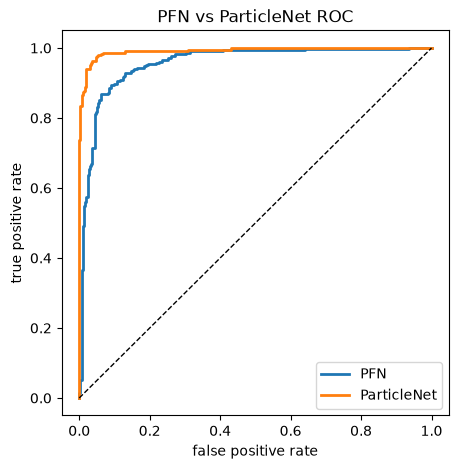

In [25]:
# Exercise 6 — PFN vs ParticleNet: where do edges help?
pfn_model = PFN(in_feat=7, n_classes=2, hidden=(64,128,128), latent=128)
pfn_model, _ = train(pfn_model, loaders, epochs=EPOCHS, quiet=True)
pfn_eval = evaluate(pfn_model, loaders["test"])

pn_model = ParticleNet(
    in_feat=7, n_classes=2, k=8,
    conv_channels=(32, 64, 64), fc=128, dropout=0.1,
    aggr="mean", dynamic=True,
)
pn_model, _ = train(pn_model, loaders, epochs=EPOCHS, quiet=True)
pn_eval = evaluate(pn_model, loaders["test"])

plt.figure(figsize=(5, 5))
for name, ev in [("PFN", pfn_eval), ("ParticleNet", pn_eval)]:
    fpr, tpr, _ = roc_curve(ev["y"], ev["p"])
    plt.plot(fpr, tpr, lw=2, label=name)
    print(f"{name}: AUC {ev['auc']:.4f} | rej@50% {background_rejection(ev['y'], ev['p'], eff=0.5):.3f}")
plt.plot([0, 1], [0, 1], '--', color='k', linewidth=1)
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("PFN vs ParticleNet ROC")
plt.legend(loc="lower right")
plt.show()

## Wrap-up

You've reached the end of the worksheet. If every exercise runs without a `NotImplementedError`, you've implemented them all — compare your results and reasoning with the solutions notebook. The through-line across the course: **every model is constrained message passing** — a choice of relations, a permutation-invariant aggregation, and a baked-in symmetry.